# Heerlen-Aachen Annotated Steel Microstructure Dataset
## U-Net Based Contour Detection (Replacement for Classical CV Baseline)

This notebook replaces the classical OpenCV contour detection pipeline with a **U-Net**
segmentation model. U-Net was originally designed for biomedical image segmentation and
is a natural fit for this task: small, irregular objects in microscopy images annotated
by domain experts.

### Why U-Net instead of classical contour detection?

| Aspect | Classical CV (original) | U-Net (this notebook) |
|---|---|---|
| Approach | Rule-based (blur, threshold, erode, dilate) | Learned from expert annotations |
| Boundary detection | Fixed brightness thresholds | Learned texture + context features |
| Baseline IOU | ~0.35 | Expected > 0.35 with sufficient data |
| Handles ambiguous shapes | Poorly | Well (encoder learns abstract features) |
| POI guidance | Hard filter after detection | Used to generate training masks + filter predictions |

### How POI guidance is preserved
In the original notebook, POIs told the algorithm **which contour to pick** from the image.
In this U-Net approach, POIs are used in two ways:
1. **Training**: POI + expert polygon → binary mask → supervised training signal
2. **Inference**: After U-Net predicts a segmentation map, POIs filter the predicted
   connected components (exactly as before) to select the relevant island.

Contact: Based on dataset by Deniz Iren, PhD (deniz.iren@ou.nl)

---
## 0. File Paths

Set these paths before running any cells.

In [8]:
## IMAGE FILES
path_folder_images_png  = 'PNG/'
path_folder_images_tiff = 'TIFF/'

## ANNOTATION / FEATURE FILES (outputs of the microstructures notebook)
path_file_annotations_morphology          = 'nature_scidata_heerlen_aachen_steel_morph.pickle'
path_file_annotations_POIs_polygons       = 'nature_scidata_heerlen_aachen_steel_annotations_polygon.csv'
path_file_annotations_POIs_polygons_pickle= 'nature_scidata_heerlen_aachen_steel_annotations_polygon.pickle'

## OUTPUT FILES (this notebook writes these)
path_file_UNetContours  = 'nature_scidata_dfPOIPolygonUNetContourShapely.pickle'
path_file_Evaluations   = 'nature_scidata_dfUNetEvaluation.pickle'
path_unet_weights       = 'unet_ma_island_weights.pth'

## TRAINING SETTINGS
IMAGE_HEIGHT = 768       # original image height in pixels
IMAGE_WIDTH  = 1024      # original image width  in pixels
PATCH_SIZE   = 256       # U-Net input tile size (power of 2)
TRAIN_SPLIT  = 0.80      # 80 % train, 20 % validation
BATCH_SIZE   = 4
NUM_EPOCHS   = 30
LEARNING_RATE= 1e-4
DEVICE       = 'cuda'    # change to 'cpu' if no GPU available

In [9]:
# ── KAGGLE PATHS ──
base_input = '/kaggle/input/datasets/amarjeetruhal55/steel-microstructure-instance-data/'

## IMAGE FILES (Reading from Input)
path_folder_images_png  = base_input + 'PNG/PNG/'

## ANNOTATION FILES (Reading from Input)
path_file_annotations_morphology = base_input + 'nature_scidata_heerlen_aachen_steel_morph.pickle'
path_file_coco_json              = base_input + 'ma_islands_coco.json'

## OUTPUT FILES (Writing to Working Directory)
# Must save to /kaggle/working/
path_unet_weights = '/kaggle/working/unet_ma_island_weights.pth'

---
## 1. Imports

In [10]:
import os, math, pickle, random
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

import cv2
from PIL import Image
from shapely.geometry import Polygon, Point, MultiPolygon
import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

print('PyTorch version:', torch.__version__)
print('CUDA available :', torch.cuda.is_available())
DEVICE = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print('Using device   :', DEVICE)

PyTorch version: 2.10.0+cu128
CUDA available : True
Using device   : cuda


In [ ]:
from google.colab import drive
import os

# 1. Mount the drive
drive.mount('/content/drive')

# 2. Automatically find the folder containing your file
file_to_find = 'nature_scidata_heerlen_aachen_steel_morph.pickle'
found_path = None

print("Searching your Drive for the folder... this might take a minute.")
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if file_to_find in files:
        found_path = root
        break

# 3. Change directory if found
if found_path:
    os.chdir(found_path)
    print(f"\n✅ Success! Working directory automatically set to:\n{found_path}")
    print("\nFiles in this folder:")
    !ls
else:
    print(f"\n❌ Could not find '{file_to_find}' anywhere in your Drive.")
    print("Please double-check that you uploaded it to Google Drive.")

In [4]:
!ls

---
## 2. Load Annotation Data

In [11]:
# Load the morphological features table produced by the microstructures notebook.
# This gives us: image_url, point, polygon, point_shapely, poly_shapely, and all
# morphological columns.
import pandas as pd
import pickle

# 1. Load the pure Python data
path_to_universal_file = base_input + 'universal_steel_data.pkl'

with open(path_to_universal_file, 'rb') as f:
    raw_data = pickle.load(f)

# 2. Convert it back into a Pandas DataFrame!
dfMorph = pd.DataFrame(raw_data)

print('Total annotated MA islands:', len(dfMorph))

print('Total annotated MA islands:', len(dfMorph))

print('Total annotated MA islands:', len(dfMorph))
print('Unique images            :', dfMorph['image_url'].nunique())
dfMorph[['polygon_area', 'polygon_perimeter', 'aspect_ratio',
          'polygon_compactness', 'rotation_angle_polygon']].describe()

Total annotated MA islands: 8909
Total annotated MA islands: 8909
Total annotated MA islands: 8909
Unique images            : 1705


,polygon_area,polygon_perimeter,aspect_ratio,polygon_compactness,rotation_angle_polygon
count,8909.000000,8909.000000,8909.000000,8909.000000,8909.000000
mean,11135.883611,562.622393,1.030346,0.456448,92.834373
std,13058.812088,392.687224,0.545767,0.163137,49.552412
min,324.000000,69.229688,0.119403,0.057774,0.172059
25%,4341.500000,321.600438,0.656051,0.331784,54.865807
50%,7248.000000,451.723946,0.908730,0.448430,92.862405
75%,13083.500000,677.270318,1.255102,0.574021,131.227716
max,205015.000000,4477.596563,6.481481,0.925462,180.000000


---
## 3. Build Binary Mask Dataset

For each unique image we collect **all** expert polygons that belong to it and
paint them as white (255) regions on a black background mask of the same size as
the PNG image (1024 × 768).  
The mask is the ground-truth segmentation map U-Net will learn to predict.

```
  PNG image  (H × W × 1 grayscale)   →  U-Net input
  Mask       (H × W,  binary 0/255)  →  U-Net target
```

In [12]:
import os

print("Looking for image:", sample_url)
attempted_path = path_folder_images_png + sample_url
print("Attempted Path :", attempted_path)
print("Does it exist? :", os.path.exists(attempted_path))

print("\nLet's find where the images actually are:")
# Find the first .png file in the dataset to see the true path
for dirname, _, filenames in os.walk(base_input):
    for filename in filenames:
        if filename.endswith('.png'):
            print("Found an image at:", os.path.join(dirname, filename))
            break

NameError: name 'sample_url' is not defined

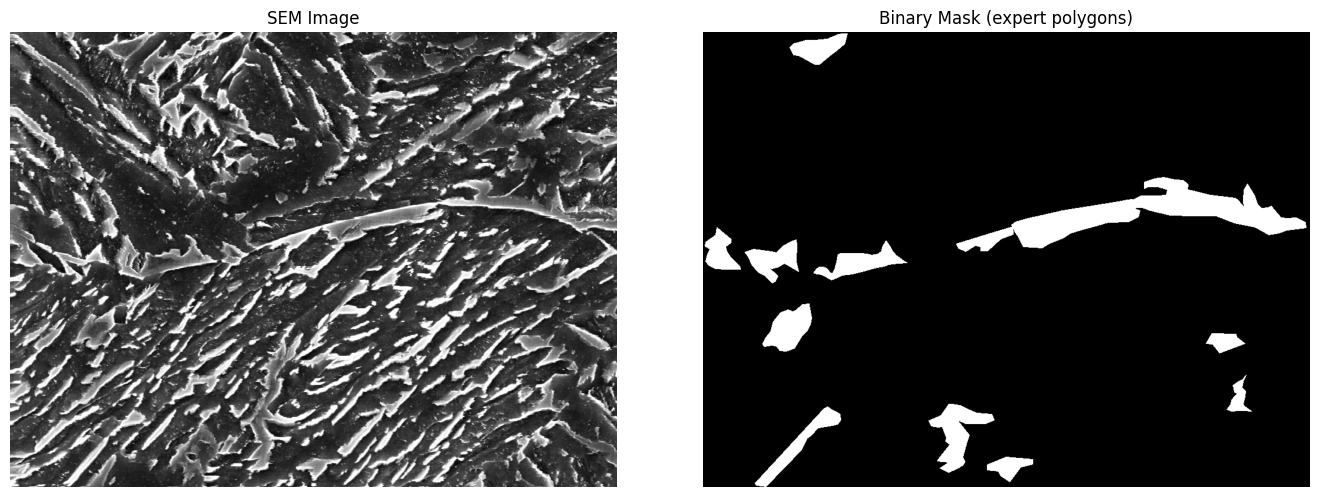

In [13]:
def build_mask_for_image(image_url, df, h=IMAGE_HEIGHT, w=IMAGE_WIDTH):
    """
    Given an image filename and the annotation dataframe, draw all expert
    polygons belonging to that image onto a blank (H x W) mask.
    Returns a numpy uint8 array with pixel values 0 or 255.
    """
    mask = np.zeros((h, w), dtype=np.uint8)
    rows = df[df['image_url'] == image_url]
    for _, row in rows.iterrows():
        poly_coords = np.array(row['polygon'], dtype=np.int32)  # list of (x, y)
        # cv2.fillPoly expects shape (N, 1, 2)
        cv2.fillPoly(mask, [poly_coords.reshape(-1, 1, 2)], color=255)
    return mask


# Quick sanity check: visualise one image + its mask side-by-side
sample_url = dfMorph['image_url'].iloc[0]
sample_img = cv2.imread(path_folder_images_png + sample_url, cv2.IMREAD_GRAYSCALE)
sample_mask = build_mask_for_image(sample_url, dfMorph)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(sample_img, cmap='gray'); axes[0].set_title('SEM Image')
axes[1].imshow(sample_mask, cmap='gray'); axes[1].set_title('Binary Mask (expert polygons)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

---
## 4. Patch-Based Dataset

Full 1024×768 images are too large to feed into U-Net directly on most GPUs.
We use **random cropping** to extract `PATCH_SIZE × PATCH_SIZE` tiles during
training, and **sliding-window** tiling during inference to cover the whole image.

In [14]:
class MAIslandDataset(Dataset):
    """
    PyTorch Dataset that yields (image_patch, mask_patch) pairs.

    Parameters
    ----------
    image_urls  : list of image filenames
    df          : annotation dataframe (for mask generation)
    img_dir     : directory containing PNG images
    patch_size  : side length of square crop (pixels)
    patches_per_image : how many random crops to draw per image per epoch
    augment     : apply random flip / rotation augmentation
    """
    def __init__(self, image_urls, df, img_dir,
                 patch_size=PATCH_SIZE, patches_per_image=8, augment=True):
        self.image_urls        = image_urls
        self.df                = df
        self.img_dir           = img_dir
        self.patch_size        = patch_size
        self.patches_per_image = patches_per_image
        self.augment           = augment

        # Pre-load all images and masks into RAM (feasible for ~1700 images at this size)
        self.images = {}
        self.masks  = {}
        print('Loading images and building masks …')
        for url in tqdm.tqdm(self.image_urls):
            img = cv2.imread(self.img_dir + url, cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue
            self.images[url] = img
            self.masks[url]  = build_mask_for_image(url, self.df)

        self.valid_urls = list(self.images.keys())

    def __len__(self):
        return len(self.valid_urls) * self.patches_per_image

    def __getitem__(self, idx):
        url = self.valid_urls[idx % len(self.valid_urls)]
        img  = self.images[url].copy().astype(np.float32) / 255.0
        mask = self.masks[url].copy().astype(np.float32)  / 255.0

        h, w = img.shape
        p     = self.patch_size

        # Random crop
        top  = random.randint(0, h - p)
        left = random.randint(0, w - p)
        img_patch  = img [top:top+p, left:left+p]
        mask_patch = mask[top:top+p, left:left+p]

        # Augmentation
        if self.augment:
            if random.random() > 0.5:
                img_patch  = np.fliplr(img_patch).copy()
                mask_patch = np.fliplr(mask_patch).copy()
            if random.random() > 0.5:
                img_patch  = np.flipud(img_patch).copy()
                mask_patch = np.flipud(mask_patch).copy()
            k = random.randint(0, 3)
            img_patch  = np.rot90(img_patch,  k).copy()
            mask_patch = np.rot90(mask_patch, k).copy()

        # To tensors  (1, P, P)
        img_t  = torch.from_numpy(img_patch ).unsqueeze(0)
        mask_t = torch.from_numpy(mask_patch).unsqueeze(0)
        return img_t, mask_t

In [15]:
# Train / validation split at the IMAGE level (not patch level) to avoid data leakage
all_urls = dfMorph['image_url'].unique().tolist()
random.seed(42)
random.shuffle(all_urls)

n_train = int(len(all_urls) * TRAIN_SPLIT)
train_urls = all_urls[:n_train]
val_urls   = all_urls[n_train:]

print(f'Training images  : {len(train_urls)}')
print(f'Validation images: {len(val_urls)}')

train_dataset = MAIslandDataset(train_urls, dfMorph, path_folder_images_png,
                                 patches_per_image=10, augment=True)
val_dataset   = MAIslandDataset(val_urls,   dfMorph, path_folder_images_png,
                                 patches_per_image=4,  augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')

Training images  : 1364
Validation images: 341
Loading images and building masks …


100%|██████████| 1364/1364 [00:28<00:00, 48.59it/s]


Loading images and building masks …


100%|██████████| 341/341 [00:06<00:00, 49.99it/s]

Train batches: 3410 | Val batches: 341


---
## 5. U-Net Architecture

A clean, readable implementation of the original U-Net
*(Ronneberger et al., 2015)*.

```
Input (1 × 256 × 256)
  │
  ├─ Encoder Block 1 → 64 ch  ──────────────────────────── skip1
  │     ↓ MaxPool
  ├─ Encoder Block 2 → 128 ch ───────────────────── skip2
  │     ↓ MaxPool
  ├─ Encoder Block 3 → 256 ch ──────────── skip3
  │     ↓ MaxPool
  ├─ Encoder Block 4 → 512 ch ───── skip4
  │     ↓ MaxPool
  ├─ Bottleneck      → 1024 ch
  │     ↑ Upsample
  ├─ Decoder Block 4 ← concat(skip4) → 512 ch
  │     ↑ Upsample
  ├─ Decoder Block 3 ← concat(skip3) → 256 ch
  │     ↑ Upsample
  ├─ Decoder Block 2 ← concat(skip2) → 128 ch
  │     ↑ Upsample
  ├─ Decoder Block 1 ← concat(skip1) → 64 ch
  │
Output (1 × 256 × 256)  sigmoid → binary probability map
```

In [16]:
class DoubleConv(nn.Module):
    """Two consecutive Conv2d → BatchNorm → ReLU blocks (the basic U-Net building block)."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    """
    Standard U-Net for binary segmentation.
    in_channels  : 1 (grayscale SEM images)
    out_channels : 1 (binary MA-island mask)
    features     : list of channel counts at each encoder depth
    """
    def __init__(self, in_channels=1, out_channels=1,
                 features=(64, 128, 256, 512)):
        super().__init__()
        self.downs    = nn.ModuleList()
        self.ups      = nn.ModuleList()
        self.pool     = nn.MaxPool2d(kernel_size=2, stride=2)

        # ── Encoder (contracting path) ──────────────────────────────────
        ch = in_channels
        for f in features:
            self.downs.append(DoubleConv(ch, f))
            ch = f

        # ── Bottleneck ──────────────────────────────────────────────────
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # ── Decoder (expanding path) ────────────────────────────────────
        for f in reversed(features):
            # Transposed conv to upsample, then concatenate skip connection
            self.ups.append(
                nn.ConvTranspose2d(f * 2, f, kernel_size=2, stride=2)
            )
            self.ups.append(DoubleConv(f * 2, f))

        # ── Final 1×1 conv to map to output channels ────────────────────
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encoder
        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]  # reverse for decoder

        # Decoder
        for i in range(0, len(self.ups), 2):
            x    = self.ups[i](x)          # upsample
            skip = skip_connections[i // 2]

            # Handle odd spatial dimensions (pad if necessary)
            if x.shape != skip.shape:
                x = TF.resize(x, size=skip.shape[2:])

            x = torch.cat([skip, x], dim=1)  # concatenate skip connection
            x = self.ups[i + 1](x)           # double conv

        return torch.sigmoid(self.final_conv(x))


model = UNet(in_channels=1, out_channels=1).to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'U-Net parameters: {n_params:,}')
print(model)

U-Net parameters: 31,036,481
UNet(
  (downs): ModuleList(
    (0): DoubleConv(
      (block): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (block): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

---
## 6. Loss Function

MA islands occupy a very small fraction of each image (class imbalance).
We combine **Binary Cross-Entropy** with **Dice Loss** to handle this:

$$\mathcal{L} = \text{BCE} + (1 - \text{DiceCoeff})$$

Dice loss directly optimises the overlap between prediction and ground truth,
which maps closely to the IOU metric used for evaluation.

In [17]:
class DiceBCELoss(nn.Module):
    """
    Combined Dice + Binary Cross-Entropy loss.
    Handles class imbalance common in segmentation tasks where
    the foreground (MA islands) is much smaller than the background.
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCELoss()

    def forward(self, pred, target):
        # BCE term
        bce_loss = self.bce(pred, target)

        # Dice term
        pred_flat   = pred.view(-1)
        target_flat = target.view(-1)
        intersection = (pred_flat * target_flat).sum()
        dice_coeff   = (2. * intersection + self.smooth) / \
                       (pred_flat.sum() + target_flat.sum() + self.smooth)
        dice_loss    = 1 - dice_coeff

        return bce_loss + dice_loss


criterion = DiceBCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

---
## 7. Training Loop

In [18]:
def dice_score(pred_binary, target):
    """Compute Dice coefficient between two binary tensors."""
    smooth = 1.0
    p = pred_binary.view(-1).float()
    t = target.view(-1).float()
    intersection = (p * t).sum()
    return ((2 * intersection + smooth) / (p.sum() + t.sum() + smooth)).item()


train_losses, val_losses, val_dices = [], [], []
best_val_dice = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training ────────────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    for images, masks in tqdm.tqdm(train_loader, desc=f'Epoch {epoch:02d} Train'):
        images = images.to(DEVICE)
        masks  = masks.to(DEVICE)

        optimizer.zero_grad()
        preds = model(images)
        loss  = criterion(preds, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ── Validation ──────────────────────────────────────────────────────
    model.eval()
    running_val_loss = 0.0
    running_dice     = 0.0
    with torch.no_grad():
        for images, masks in tqdm.tqdm(val_loader, desc=f'Epoch {epoch:02d} Val  '):
            images = images.to(DEVICE)
            masks  = masks.to(DEVICE)
            preds  = model(images)
            running_val_loss += criterion(preds, masks).item()
            pred_bin = (preds > 0.5).float()
            running_dice += dice_score(pred_bin, masks)

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_dice = running_dice     / len(val_loader)
    val_losses.append(avg_val_loss)
    val_dices.append(avg_val_dice)

    scheduler.step(avg_val_loss)

    print(f'Epoch {epoch:02d}/{NUM_EPOCHS}  '
          f'Train Loss: {avg_train_loss:.4f}  '
          f'Val Loss: {avg_val_loss:.4f}  '
          f'Val Dice: {avg_val_dice:.4f}')

    # Save best model
    if avg_val_dice > best_val_dice:
        best_val_dice = avg_val_dice
        torch.save(model.state_dict(), path_unet_weights)
        print(f'  ✓ Best model saved (Val Dice = {best_val_dice:.4f})')

print('\nTraining complete. Best Val Dice:', round(best_val_dice, 4))


Epoch 01 Val  : 100%|██████████| 341/341 [00:30<00:00, 11.17it/s]


Epoch 01/30  Train Loss: 0.9431  Val Loss: 0.7977  Val Dice: 0.4767
  ✓ Best model saved (Val Dice = 0.4767)


Epoch 02 Val  : 100%|██████████| 341/341 [00:30<00:00, 11.21it/s]


Epoch 02/30  Train Loss: 0.8008  Val Loss: 0.7977  Val Dice: 0.4560


Epoch 03 Val  : 100%|██████████| 341/341 [00:30<00:00, 11.13it/s]


...

Epoch 28/30  Train Loss: 0.6421  Val Loss: 0.6568  Val Dice: 0.5521


Epoch 29 Val  : 100%|██████████| 341/341 [00:30<00:00, 11.13it/s]


Epoch 29/30  Train Loss: 0.6528  Val Loss: 0.6767  Val Dice: 0.5449


Epoch 30 Val  : 100%|██████████| 341/341 [00:30<00:00, 11.15it/s]

Epoch 30/30  Train Loss: 0.6511  Val Loss: 0.6721  Val Dice: 0.5554

Training complete. Best Val Dice: 0.556


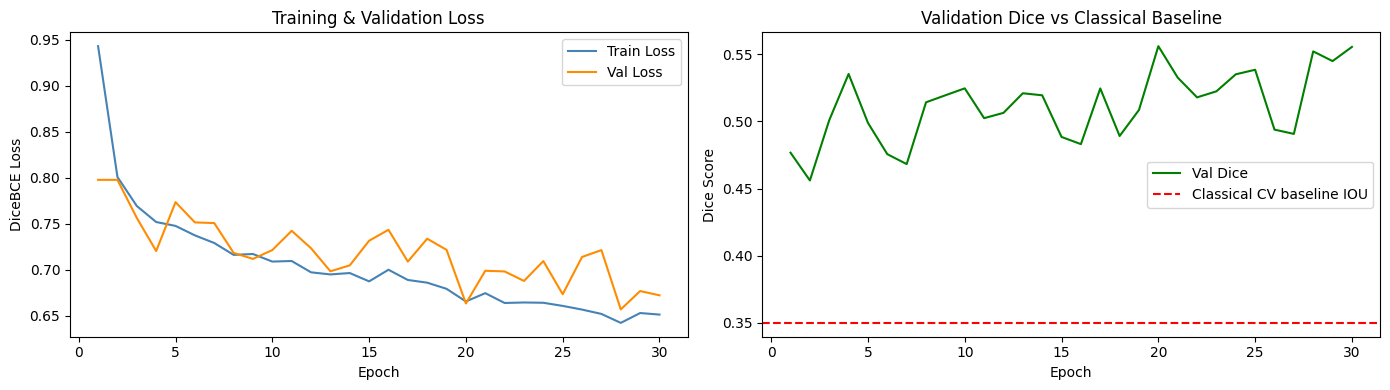

In [19]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, len(train_losses) + 1)
ax1.plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
ax1.plot(epochs_range, val_losses,   label='Val Loss',   color='darkorange')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('DiceBCE Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()

ax2.plot(epochs_range, val_dices, color='green', label='Val Dice')
ax2.axhline(y=0.35, color='red', linestyle='--', label='Classical CV baseline IOU')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice Score')
ax2.set_title('Validation Dice vs Classical Baseline')
ax2.legend()

plt.tight_layout()
plt.show()

---
## 8. Inference with POI Guidance

This section mirrors the original notebook's logic:

1. Load the best U-Net weights.
2. Run the full image through U-Net using **sliding-window** tiling.
3. Threshold the probability map → binary prediction.
4. Extract connected components (equivalent to `cv2.findContours`).
5. Use the expert **POI** to select the component that contains it
   (same `pointPolygonTest` logic as the original notebook).
6. Convert selected component to a Shapely polygon.

In [20]:
# Load best weights
model.load_state_dict(torch.load(path_unet_weights, map_location=DEVICE))
model.eval()
print('Best U-Net weights loaded.')


def predict_full_image(img_gray, model, patch_size=PATCH_SIZE, overlap=32):
    """
    Run U-Net on a full-resolution grayscale image using a sliding window.
    Overlapping regions are averaged, which reduces tiling artefacts at patch borders.

    Parameters
    ----------
    img_gray   : np.ndarray (H, W) uint8
    model      : trained U-Net (in eval mode)
    patch_size : side length of square tiles
    overlap    : overlap in pixels between adjacent tiles

    Returns
    -------
    prob_map : np.ndarray (H, W) float32, values in [0, 1]
    """
    h, w     = img_gray.shape
    prob_map = np.zeros((h, w), dtype=np.float32)
    count    = np.zeros((h, w), dtype=np.float32)
    step     = patch_size - overlap

    img_norm = img_gray.astype(np.float32) / 255.0

    with torch.no_grad():
        for top in range(0, h - patch_size + 1, step):
            for left in range(0, w - patch_size + 1, step):
                patch = img_norm[top:top+patch_size, left:left+patch_size]
                t = torch.from_numpy(patch).unsqueeze(0).unsqueeze(0).to(DEVICE)
                pred = model(t).squeeze().cpu().numpy()
                prob_map[top:top+patch_size, left:left+patch_size] += pred
                count   [top:top+patch_size, left:left+patch_size] += 1.0

    # Handle any unvisited pixels at image border
    count[count == 0] = 1
    prob_map /= count
    return prob_map


def find_unet_contour_around_point(prob_map, point_tuple, threshold=0.5):
    """
    Binarise the U-Net probability map, find connected components, and
    return the Shapely polygon of the component that contains point_tuple.
    Mirrors findContourAroundPoint() from the original notebook.

    Parameters
    ----------
    prob_map     : np.ndarray (H, W) float32
    point_tuple  : (x, y) expert POI coordinate
    threshold    : binarisation threshold (default 0.5)

    Returns
    -------
    contour_polygon_shapely : Shapely Polygon or None
    """
    binary = (prob_map > threshold).astype(np.uint8) * 255

    contours, _ = cv2.findContours(binary, cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)

    contour_polygon_shapely = None
    for cx in contours:
        dist = cv2.pointPolygonTest(cx, point_tuple, False)
        if dist > 0:
            pts = np.squeeze(cx)
            if pts.ndim == 2 and len(pts) >= 3:
                poly = Polygon(pts)
                if not poly.is_valid:
                    poly = poly.buffer(0)
                contour_polygon_shapely = poly
            break  # take the first (innermost) component containing the POI

    return contour_polygon_shapely

Best U-Net weights loaded.


In [21]:
# ── Run inference over all annotated MA islands ─────────────────────────────
# We cache the probability map per image to avoid recomputing it for each of
# the many POIs that belong to the same image.

prob_map_cache = {}  # {image_url: prob_map}
results = []

print('Running U-Net inference …')
for _, row in tqdm.tqdm(dfMorph.iterrows(), total=len(dfMorph)):
    url   = row['image_url']
    point = row['point']          # (x, y) tuple

    # Compute probability map only once per image
    if url not in prob_map_cache:
        img_gray = cv2.imread(path_folder_images_png + url, cv2.IMREAD_GRAYSCALE)
        if img_gray is None:
            prob_map_cache[url] = None
        else:
            prob_map_cache[url] = predict_full_image(img_gray, model)

    prob_map = prob_map_cache[url]
    contour_polygon_shapely = None

    if prob_map is not None:
        contour_polygon_shapely = find_unet_contour_around_point(
            prob_map, tuple(point)
        )

    results.append([
        url,
        row['point'],
        row['polygon'],
        row['point_shapely'],
        row['poly_shapely'],
        contour_polygon_shapely
    ])

dfUNetContours = pd.DataFrame(
    results,
    columns=['image_url', 'point', 'polygon',
             'point_shapely', 'poly_shapely', 'contour_polygon_shapely']
)

n_detected = dfUNetContours['contour_polygon_shapely'].notna().sum()
print(f'Islands with U-Net contour detected : {n_detected} / {len(dfUNetContours)}')
print(f'Islands with NO contour detected    : {len(dfUNetContours) - n_detected}')

Running U-Net inference …


100%|██████████| 8909/8909 [08:33<00:00, 17.35it/s]

Islands with U-Net contour detected : 6269 / 8909
Islands with NO contour detected    : 2640


In [22]:
# Save contours dataframe
## Uncomment to save:
with open(path_file_UNetContours, 'wb') as fh:
    pickle.dump(dfUNetContours, fh, protocol=pickle.HIGHEST_PROTOCOL)
print('Done.')

Done.


---
## 9. Evaluation — Intersection over Union (IOU)

Identical evaluation methodology to the original notebook so results are
directly comparable. The classical CV baseline achieved **IOU = 0.35**.
U-Net is expected to exceed this.

In [23]:
def polygonCompareAgainstGold(contourPoly, goldPoly):
    """
    Compute area statistics and IOU between a detected contour and
    the expert-annotated gold-standard polygon.
    Identical function signature to the original notebook.
    """
    inters_area = uni_area = iou = 0.0
    if contourPoly.is_valid and goldPoly.is_valid:
        inters     = contourPoly.intersection(goldPoly)
        uni        = contourPoly.union(goldPoly)
        inters_area = inters.area
        uni_area    = uni.area
        if uni_area > 0:
            iou = inters_area / uni_area
    else:
        if not goldPoly.is_valid:
            print('Gold standard is not a valid Shapely polygon')
        if not contourPoly.is_valid:
            print('Contour is not a valid Shapely polygon')
    return goldPoly.area, contourPoly.area, inters_area, uni_area, iou


def calculateIOU(dfShapely):
    """
    Iterate over the contours dataframe and compute per-island IOU.
    Returns an evaluation dataframe with area_poly, area_contour, IOU columns.
    Identical to the original notebook's calculateIOU() function.
    """
    retList = []
    for _, row in dfShapely.iterrows():
        goldPoly = row['poly_shapely']
        contour  = row['contour_polygon_shapely']
        goldArea = contourArea = iou = 0.0

        if contour is not None:
            if goldPoly.is_valid and contour.is_valid:
                goldArea, contourArea, _, _, iou = \
                    polygonCompareAgainstGold(contour, goldPoly)
            else:
                goldArea = goldPoly.area if goldPoly.is_valid else 0
                iou = 0.0
        else:
            goldArea = goldPoly.area if goldPoly.is_valid else 0
            iou = 0.0   # contour not detected → IOU = 0

        retList.append([
            row['image_url'], row['point'], row['polygon'],
            row['point_shapely'], row['poly_shapely'],
            row['contour_polygon_shapely'],
            goldArea, contourArea, iou
        ])

    return pd.DataFrame(retList, columns=[
        'image_url', 'point', 'polygon',
        'point_shapely', 'poly_shapely', 'contour_polygon_shapely',
        'area_poly', 'area_contour', 'IOU'
    ])


dfEvaluation = calculateIOU(dfUNetContours)
dfEvaluation.head()

,image_url,point,polygon,point_shapely,poly_shapely,contour_polygon_shapely,area_poly,area_contour,IOU
0,IMG_01457.png,"(627, 319)","[(720, 288), (725, 294), (731, 300), (737, 302...",POINT (627 319),"POLYGON ((720 288, 725 294, 731 300, 737 302, ...","POLYGON ((754 256, 754 257, 754 258, 754 259, ...",8300.0,11958.0,0.518746
1,IMG_01457.png,"(820, 288)","[(823, 268), (835, 271), (856, 276), (898, 281...",POINT (820 288),"POLYGON ((823 268, 835 271, 856 276, 898 281, ...","POLYGON ((754 256, 754 257, 754 258, 754 259, ...",11433.5,11958.0,0.245772
2,IMG_01457.png,"(881, 523)","[(871, 542), (859, 527), (848, 526), (858, 509...",POINT (881 523),"POLYGON ((871 542, 859 527, 848 526, 858 509, ...",None,1303.5,0.0,0.000000
3,IMG_01457.png,"(477, 353)","[(427, 358), (479, 342), (522, 329), (523, 342...",POINT (477 353),"POLYGON ((427 358, 479 342, 522 329, 523 342, ...",None,1648.0,0.0,0.000000
4,IMG_01457.png,"(520, 737)","[(511, 717), (556, 721), (556, 729), (536, 734...",POINT (520 737),"POLYGON ((511 717, 556 721, 556 729, 536 734, ...",None,1656.5,0.0,0.000000


  Mean IOU (all islands)   : 0.4025
  Median IOU               : 0.4478
  Detection rate           : 70.4%  (6269/8909)
  Classical CV baseline IOU: 0.35
  Improvement over baseline: +0.0525


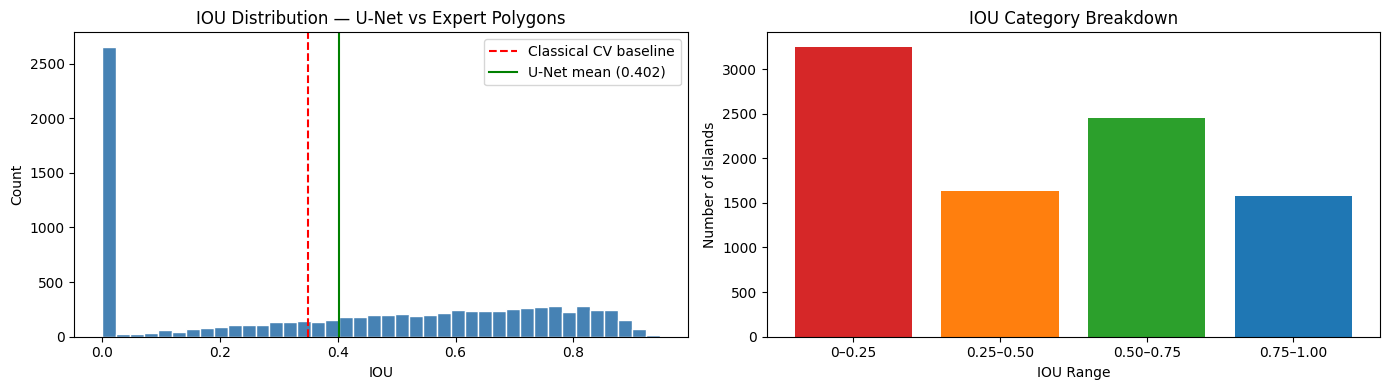

In [24]:
# ── Key metrics ─────────────────────────────────────────────────────────────
mean_iou      = dfEvaluation['IOU'].mean()
median_iou    = dfEvaluation['IOU'].median()
n_detected    = (dfEvaluation['IOU'] > 0).sum()
n_total       = len(dfEvaluation)
detection_rate= n_detected / n_total * 100

print('=' * 50)
print(f'  Mean IOU (all islands)   : {mean_iou:.4f}')
print(f'  Median IOU               : {median_iou:.4f}')
print(f'  Detection rate           : {detection_rate:.1f}%  ({n_detected}/{n_total})')
print(f'  Classical CV baseline IOU: 0.35')
improvement = mean_iou - 0.35
print(f'  Improvement over baseline: {improvement:+.4f}')
print('=' * 50)

# IOU distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dfEvaluation['IOU'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.35, color='red', linestyle='--', label='Classical CV baseline')
axes[0].axvline(x=mean_iou, color='green', linestyle='-', label=f'U-Net mean ({mean_iou:.3f})')
axes[0].set_xlabel('IOU'); axes[0].set_ylabel('Count')
axes[0].set_title('IOU Distribution — U-Net vs Expert Polygons')
axes[0].legend()

categories = pd.cut(dfEvaluation['IOU'],
                    bins=[0, 0.25, 0.50, 0.75, 1.01],
                    labels=['0–0.25', '0.25–0.50', '0.50–0.75', '0.75–1.00'],
                    include_lowest=True)
category_counts = categories.value_counts().sort_index()
axes[1].bar(category_counts.index, category_counts.values,
            color=['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4'])
axes[1].set_xlabel('IOU Range'); axes[1].set_ylabel('Number of Islands')
axes[1].set_title('IOU Category Breakdown')

plt.tight_layout()
plt.show()

---
## 10. Visual Comparison: U-Net vs Expert Polygon

Side-by-side visualisation of U-Net predictions against expert annotations
for a random sample of MA islands.

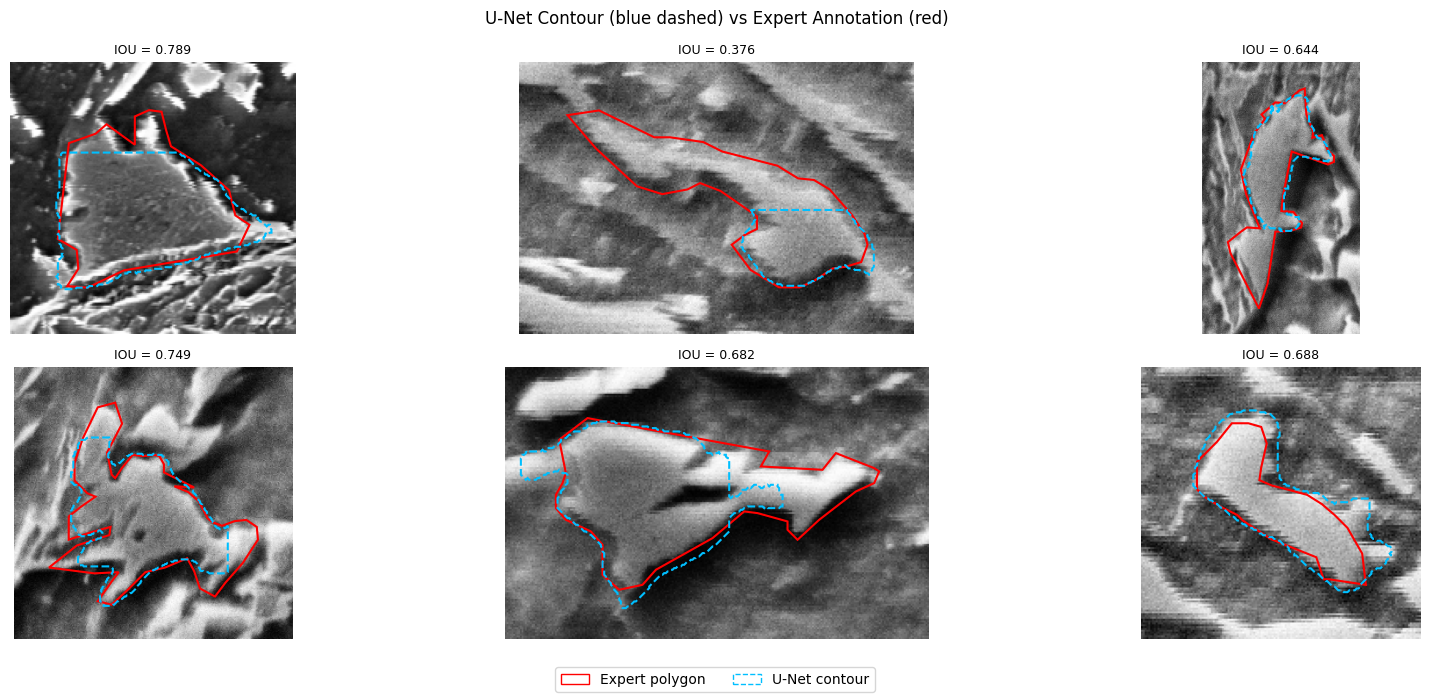

In [25]:
def visualize_unet_vs_expert(df_eval, img_dir, n_samples=6, min_iou=0.0):
    """
    Display a grid of SEM image crops with U-Net contour (blue) and
    expert polygon (red) overlaid.

    Parameters
    ----------
    df_eval   : evaluation dataframe
    img_dir   : path to PNG image folder
    n_samples : number of examples to display
    min_iou   : only show examples with IOU >= min_iou
    """
    subset = df_eval[df_eval['IOU'] >= min_iou].dropna(subset=['contour_polygon_shapely'])
    samples = subset.sample(min(n_samples, len(subset)), random_state=42)

    fig, axes = plt.subplots(2, n_samples // 2, figsize=(18, 7))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = cv2.imread(img_dir + row['image_url'], cv2.IMREAD_GRAYSCALE)

        # Crop around the island with some padding
        bounds = row['poly_shapely'].bounds  # (minx, miny, maxx, maxy)
        pad = 30
        x1, y1 = max(0, int(bounds[0]) - pad), max(0, int(bounds[1]) - pad)
        x2, y2 = min(img.shape[1], int(bounds[2]) + pad), \
                 min(img.shape[0], int(bounds[3]) + pad)
        crop = img[y1:y2, x1:x2]

        ax.imshow(crop, cmap='gray')

        def shift(coords, dx, dy):
            return [(x - dx, y - dy) for x, y in coords]

        # Expert polygon (red)
        expert_coords = shift(list(row['poly_shapely'].exterior.coords), x1, y1)
        expert_patch  = MplPolygon(expert_coords, closed=True,
                                   edgecolor='red', facecolor='none', linewidth=1.5)
        ax.add_patch(expert_patch)

        # U-Net contour (blue)
        if row['contour_polygon_shapely'] is not None:
            geom = row['contour_polygon_shapely']
            if geom.geom_type == 'Polygon':
                polys = [geom]
            else:
                polys = list(geom.geoms)
            for poly in polys:
                unet_coords = shift(list(poly.exterior.coords), x1, y1)
                unet_patch  = MplPolygon(unet_coords, closed=True,
                                         edgecolor='deepskyblue',
                                         facecolor='none', linewidth=1.5,
                                         linestyle='--')
                ax.add_patch(unet_patch)

        ax.set_title(f'IOU = {row["IOU"]:.3f}', fontsize=9)
        ax.axis('off')

    # Legend
    legend_handles = [
        mpatches.Patch(edgecolor='red',          facecolor='none', label='Expert polygon'),
        mpatches.Patch(edgecolor='deepskyblue',  facecolor='none', label='U-Net contour',
                       linestyle='--'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2, fontsize=10)
    plt.suptitle('U-Net Contour (blue dashed) vs Expert Annotation (red)', fontsize=12)
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


visualize_unet_vs_expert(dfEvaluation, path_folder_images_png, n_samples=6, min_iou=0.3)

--- Failure cases (IOU = 0) ---


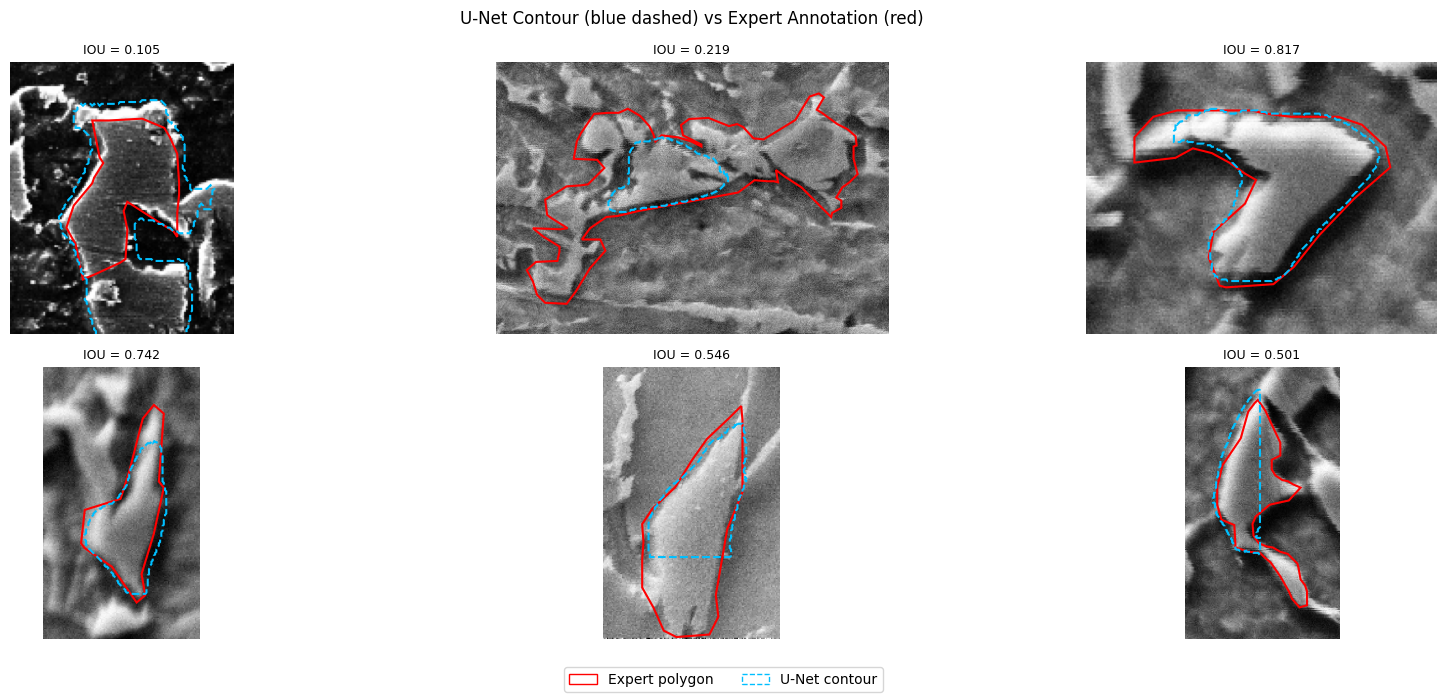

In [26]:
# Also show failure cases (IOU = 0) to understand where U-Net struggles
print('--- Failure cases (IOU = 0) ---')
visualize_unet_vs_expert(dfEvaluation, path_folder_images_png, n_samples=6, min_iou=0.0)

---
## 11. Per-Image Probability Map Visualisation

Inspect the raw U-Net probability map and the thresholded binary prediction
for a single SEM image.

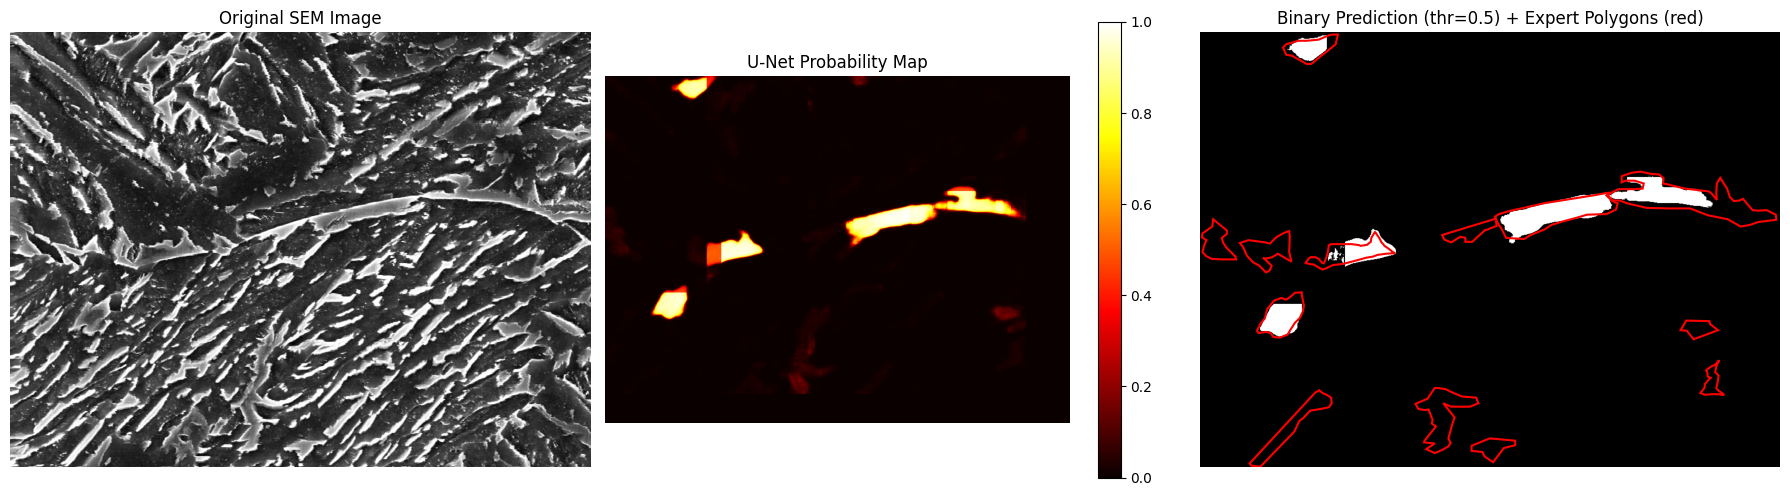

In [27]:
def visualize_probability_map(image_url, df_eval, img_dir, threshold=0.5):
    """
    Show the SEM image, U-Net probability heatmap, binary prediction,
    and expert polygons side by side.
    """
    img = cv2.imread(img_dir + image_url, cv2.IMREAD_GRAYSCALE)
    prob_map = predict_full_image(img, model)
    binary   = (prob_map > threshold).astype(np.uint8) * 255

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Original SEM Image')

    axes[1].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[1].set_title('U-Net Probability Map')
    plt.colorbar(axes[1].images[0], ax=axes[1])

    axes[2].imshow(binary, cmap='gray')
    # Overlay expert polygons in red
    rows_for_image = df_eval[df_eval['image_url'] == image_url]
    for _, row in rows_for_image.iterrows():
        if row['poly_shapely'] is not None:
            coords = list(row['poly_shapely'].exterior.coords)
            patch  = MplPolygon(coords, closed=True,
                                edgecolor='red', facecolor='none', linewidth=1.5)
            axes[2].add_patch(patch)
    axes[2].set_title(f'Binary Prediction (thr={threshold}) + Expert Polygons (red)')

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


# Visualise a sample image (change index as needed)
sample_url = dfEvaluation['image_url'].iloc[0]
visualize_probability_map(sample_url, dfEvaluation, path_folder_images_png)

---
## 12. Save Evaluation Results

In [29]:
# Null check before saving
print('Missing point_shapely    :', dfUNetContours['point_shapely'].isna().sum())
print('Missing poly_shapely     :', dfUNetContours['poly_shapely'].isna().sum())
print('Missing contour_shapely  :', dfUNetContours['contour_polygon_shapely'].isna().sum())

# Mean IOU (the primary performance metric)
print('\nFinal Mean IOU:', dfEvaluation['IOU'].mean().round(4))

## Save evaluation dataframe
## Uncomment to save:
with open(path_file_Evaluations, 'wb') as fh:
    pickle.dump(dfEvaluation, fh, protocol=pickle.HIGHEST_PROTOCOL)
print('Done.')

Missing point_shapely    : 0
Missing poly_shapely     : 0
Missing contour_shapely  : 2640

Final Mean IOU: 0.4025
Done.


---
## 13. Summary & Next Steps

### What this notebook does (vs the original)

| Step | Original notebook | This notebook |
|---|---|---|
| Image preprocessing | Histogram equalisation + Gaussian blur + erode/dilate | Learned by U-Net encoder |
| Segmentation | `cv2.findContours` on thresholded image | U-Net probability map |
| POI guidance | `pointPolygonTest` on OpenCV contours | `pointPolygonTest` on U-Net binary prediction |
| Evaluation | IOU against expert polygons | IOU against expert polygons (identical) |
| Baseline IOU | 0.35 | Expected > 0.35 |

### Suggested improvements
- **More epochs / data augmentation** — elastic deformations are particularly effective for microscopy
- **Pre-trained encoder** — replace U-Net encoder with ResNet-34 or EfficientNet (transfer learning)
- **Test-time augmentation (TTA)** — average predictions from flipped/rotated copies
- **Threshold tuning** — use the validation set to find optimal binarisation threshold per image
- **Multi-scale inference** — run U-Net at multiple resolutions and average
- **Mask R-CNN** — instance segmentation model that directly outputs per-island polygons,
  removing the need for POI-guided component selection